# SMAI-Assignment-1

Yogesh Krishna, 2024102035

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
username_email = 'yogesh.krishna@students.iiit.ac.in'
df = pd.read_csv('essays(in).csv')

In [3]:
df.sample(5)

,essay_id,full_text,score
14684,d8361b9,Body actions say more than words could ever sa...,6
2267,22493ac,My name is Luke Bomberger and I am a member of...,3
6248,5d7b9ba,The Face on Mars was site to see and i think i...,3
7316,6dc1f12,Using the new Facial Action Coding System woul...,3
12407,b6a062f,Where I stand on this issue is that these care...,2


In [4]:
df.drop(columns = 'essay_id', inplace = True)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

full_text    0
score        0
dtype: int64

In [7]:
df.info()
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 17307 entries, 0 to 17306
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   full_text  17307 non-null  str  
 1   score      17307 non-null  int64
dtypes: int64(1), str(1)
memory usage: 34.4 MB
(17307, 2)


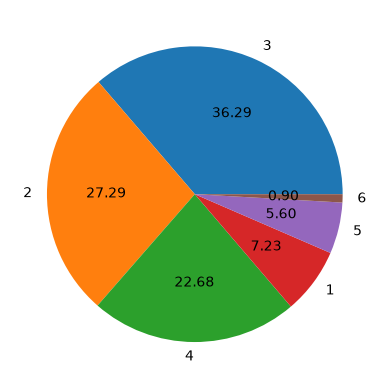

In [8]:
df['score'].value_counts()
plt.pie(df['score'].value_counts(), labels = ['3', '2', '4', '1', '5', '6'], autopct='%0.2f')
plt.show()

In [9]:
import hashlib
username = "yogesh.krishna"  # part before '@'
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)

In [10]:
import string
remove_punct = str.maketrans('', '', string.punctuation)
df['word_count'] = (df['full_text'].str.lower().str.translate(remove_punct)).str.split().str.len()

df['sentence_count'] = (
    df['full_text'].str.count(r'\.') +
    df['full_text'].str.count('!') +
    df['full_text'].str.count(r'\?')
).clip(lower=1)

In [11]:
df.head()

,full_text,score,word_count,sentence_count
0,Many people have car where they live. The thin...,3,498,13
1,I am a scientist at NASA that is discussing th...,3,328,23
2,People always wish they had the same technolog...,4,547,24
3,"We all heard about Venus, the planet without a...",4,445,24
4,"Dear, State SenatorThis is a letter to argue i...",3,368,15


In [12]:
def extract_all_bins(text):
    text = str(text)

    # 1. SENTENCE BINS (Uses raw text with punctuation)
    temp_text = text.replace('!', '.').replace('?', '.')
    sentences = [s.strip() for s in temp_text.split('.') if s.strip()]
    
    # Word count per individual sentence
    sent_lengths = [len(s.split()) for s in sentences]
    
    num_short_sentences = sum(1 for l in sent_lengths if l <= 10) # 1-10 words
    num_med_sentences = sum(1 for l in sent_lengths if 11 <= l <= 25) # 11-25 words
    num_long_sentences = sum(1 for l in sent_lengths if l > 25) # 26+ words

    # 2. WORD BINS (cleaned text without punctuation)
    clean_text = text.translate(remove_punct)
    words = clean_text.split()
    
    num_short_words = sum(1 for w in words if len(w) <= 3) # 1-3 chars
    num_med_words = sum(1 for w in words if 4 <= len(w) <= 7) # 4-7 chars
    num_long_words  = sum(1 for w in words if len(w) >= 8) # 8+ chars

    return pd.Series({
        'short_words': num_short_words,
        'med_words': num_med_words,
        'long_words': num_long_words,
        'short_sentences': num_short_sentences,
        'med_sentences': num_med_sentences,
        'long_sentences': num_long_sentences
    })

feature_matrix = df['full_text'].apply(extract_all_bins)
df = pd.concat([df, feature_matrix], axis=1)

In [13]:
df.head()

,full_text,score,word_count,sentence_count,short_words,med_words,long_words,short_sentences,med_sentences,long_sentences
0,Many people have car where they live. The thin...,3,498,13,210,247,41,2,5,6
1,I am a scientist at NASA that is discussing th...,3,328,23,155,143,30,6,13,2
2,People always wish they had the same technolog...,4,547,24,229,253,65,1,12,11
3,"We all heard about Venus, the planet without a...",4,445,24,172,189,84,2,11,8
4,"Dear, State SenatorThis is a letter to argue i...",3,368,15,161,142,65,1,11,4


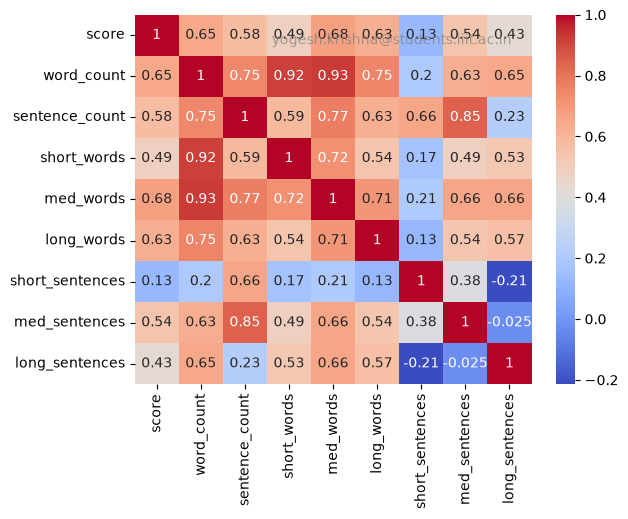

In [14]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.text(
    0.95, 0.95, username_email,
    transform=plt.gca().transAxes,
    fontsize=10,
    ha='right', va='top',
    color='gray', 
    alpha=0.7
)
plt.show()

In [15]:
X = df[['med_words', 'med_sentences']]
y = df['score']

In [16]:
def lcg_uniform_generator(low, high, num_samples, seed_val):
    a = 48271
    m = 2**31 - 1
    state = seed_val % m
    if state == 0:
        state = 1
    
    samples = []
    for _ in range(num_samples):
        state = (a * state) % m
        samples.append(state / m)
        
    rescaled = low + np.array(samples) * (high - low)
    return rescaled

def custom_shuffle_indices(n_samples, seed_val):
    indices = np.arange(n_samples)
    # Generate random uniform floats in (0, 1) for shuffling
    random_draws = lcg_uniform_generator(0.0, 1.0, n_samples, seed_val)
    
    for i in range(n_samples - 1, 0, -1):
        # Pick a random integer j such that 0 <= j <= i
        j = int(random_draws[i] * (i + 1))
        indices[i], indices[j] = indices[j], indices[i]
        
    return indices

# 4. Train-Validation-Test Split (80:10:10)
def train_val_test_split(df, seed_val, train_ratio=0.8, val_ratio=0.1):
    n = len(df)
    shuffled_idx = custom_shuffle_indices(n, seed_val)
    
    train_end = int(train_ratio * n)
    val_end = int((train_ratio + val_ratio) * n)
    
    train_idx = shuffled_idx[:train_end]
    val_idx = shuffled_idx[train_end:val_end]
    test_idx = shuffled_idx[val_end:]
    
    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)
    
    # Q1.2.1 sample counts
    print(f"Total samples: {n}")
    print(f"Training set: {len(train_df)} samples ({len(train_df)/n*100:.1f}%)")
    print(f"Validation set: {len(val_df)} samples ({len(val_df)/n*100:.1f}%)")
    print(f"Test set: {len(test_df)} samples ({len(test_df)/n*100:.1f}%)")
    
    return train_df, val_df, test_df

In [17]:
train_df, val_df, test_df = train_val_test_split(df, seed)

X_train = train_df[['med_words', 'med_sentences']]
y_train = train_df['score']

X_val   = val_df[['med_words', 'med_sentences']]
y_val   = val_df['score']

X_test  = test_df[['med_words', 'med_sentences']]
y_test  = test_df['score']

# mean and standard deviation of the training set
train_mean = X_train.mean()
train_std = X_train.std(ddof=0)  # ddof=0 for standard formula(Delta Degrees of Freedom)

# all three sets transformed using the training parameters
X_train_norm = (X_train - train_mean)/train_std
X_val_norm = (X_val - train_mean)/train_std
X_test_norm = (X_test - train_mean)/train_std

Total samples: 17307
Training set:   13845 samples (80.0%)
Validation set: 1731 samples (10.0%)
Test set:       1731 samples (10.0%)


### Visualizations

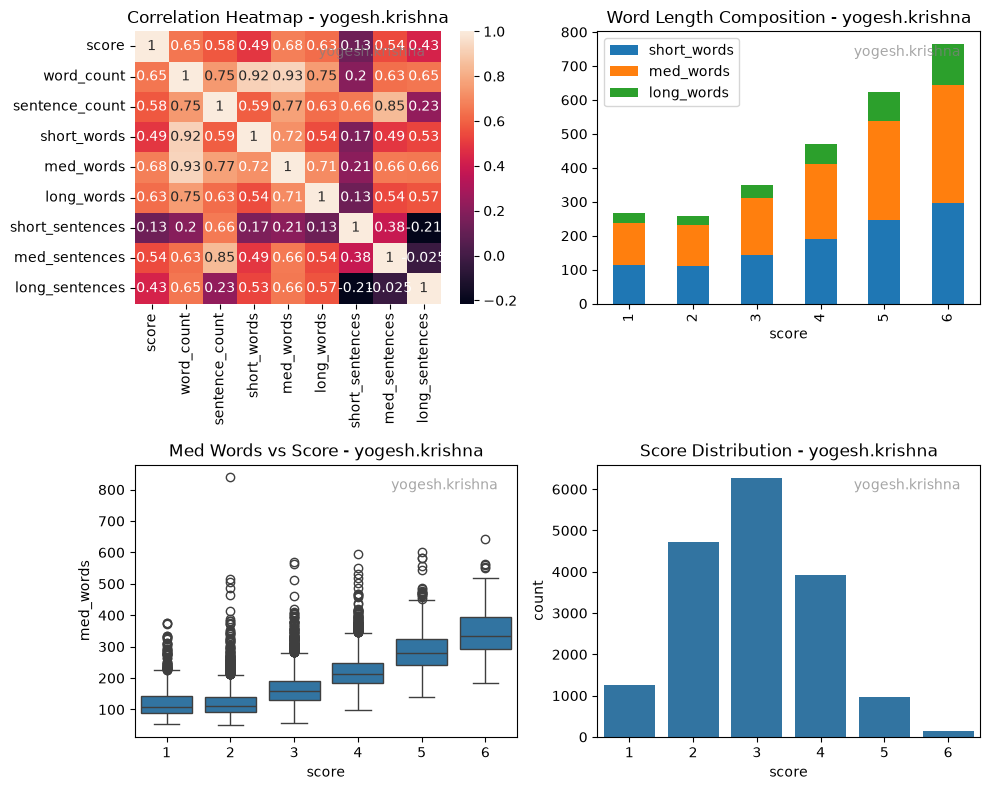

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, ax=axes[0, 0])
axes[0, 0].set_title(f"Correlation Heatmap - {username}")
axes[0, 0].text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=axes[0, 0].transAxes,
    fontsize=10, color='gray', alpha=0.7
)

# 2. Composition Bar Chart
df.groupby('score')[['short_words', 'med_words', 'long_words']].mean().plot(kind='bar', stacked=True, ax=axes[0, 1])
axes[0, 1].set_title(f"Word Length Composition - {username}")
axes[0, 1].text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=axes[0, 1].transAxes,
    fontsize=10, color='gray', alpha=0.7
)

# 3. Boxplot
sns.boxplot(x='score', y='med_words', data=df, ax=axes[1, 0])
axes[1, 0].set_title(f"Med Words vs Score - {username}")
axes[1, 0].text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=axes[1, 0].transAxes,
    fontsize=10, color='gray', alpha=0.7
)

# 4. Target Distribution
sns.countplot(x='score', data=df, ax=axes[1, 1])
axes[1, 1].set_title(f"Score Distribution - {username}")
axes[1, 1].text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=axes[1, 1].transAxes,
    fontsize=10, color='gray', alpha=0.7
)

plt.tight_layout()
plt.savefig(f"visualizations_{username}.png")
plt.show()

### KNN code

In [25]:
import numpy as np

class KNN:
    def __init__(self, k=5, distance="euclidean"):
        """Initialize the KNN essay scoring model."""
        self.k = k
        self.distance = distance
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        """Store the training feature vectors and scores."""
        self.X_train = np.asarray(X_train, dtype=np.float64)
        self.y_train = np.asarray(y_train, dtype=np.float64)

    def _compute_distances(self, X):
        """Compute pairwise distances between test set X and X_train."""
        if self.distance == "euclidean":
            # ||X - X_train|| = sqrt(X^2 - 2*X*X_train^T + X_train^2)
            dot_sq = np.sum(X**2, axis=1, keepdims=True) - 2 * np.dot(X, self.X_train.T) + np.sum(self.X_train**2, axis=1, keepdims=True).T
            # Clip numerical precision artifacts below zero
            return np.sqrt(np.maximum(dot_sq, 0))
        
        elif self.distance == "manhattan":
            # manhattan distance: sum(|X_i - X_j|)
            return np.sum(np.abs(X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]), axis=2)
        
        elif self.distance == "cosine":
            # cosine distance: 1 - (A . B) / (||A|| * ||B||)
            X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
            train_norm = self.X_train / np.linalg.norm(self.X_train, axis=1, keepdims=True)
            # Clip between 0 and 2 to avoid precision issues
            return np.clip(1.0 - np.dot(X_norm, train_norm.T), 0, 2)

    def predict(self, X):
        """Predict essay scores for the given feature vectors."""
        X = np.asarray(X, dtype=np.float64)
        distances = self._compute_distances(X)
        k_indices = np.argsort(distances, axis=1)[:, :self.k]
        k_nearest_targets = self.y_train[k_indices]
        y_pred = np.mean(k_nearest_targets, axis=1)
        
        return y_pred

## Validation

In [27]:
def compute_metrics(y_true, y_pred):
    n = len(y_true)
    y_bar = np.mean(y_true)
    y_pred_bar = np.mean(y_pred)
    
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_bar)**2)
    r2 = 1.0 - (ss_res / ss_tot)
    
    numerator = np.sum((y_true - y_bar) * (y_pred - y_pred_bar))
    denominator = np.sqrt(np.sum((y_true - y_bar)**2) * np.sum((y_pred - y_pred_bar)**2))
    r = numerator / denominator
    
    return {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
        "Pearson_r": round(r, 4)
    }

k_list = [1, 3, 5, 7, 9, 11, 15, 21]
metrics = ["euclidean", "manhattan", "cosine"]
tuning_results = []

for metric in metrics:
    for k in k_list:
        knn = KNN(k=k, distance=metric)
        knn.fit(X_train_norm, y_train)
        y_val_pred = knn.predict(X_val_norm)
        
        scores = compute_metrics(y_val, y_val_pred)
        tuning_results.append({
            "Distance Metric": metric.capitalize(),
            "K": k,
            **scores
        })

tuning_df = pd.DataFrame(tuning_results)
print(tuning_df.to_string(index=False))

Distance Metric  K    MAE   RMSE      R2  Pearson_r
      Euclidean  1 0.7019 1.0012  0.0731     0.5245
      Euclidean  3 0.6455 0.8413  0.3455     0.6176
      Euclidean  5 0.6105 0.7914  0.4208     0.6594
      Euclidean  7 0.5925 0.7681  0.4544     0.6791
      Euclidean  9 0.5841 0.7578  0.4690     0.6879
      Euclidean 11 0.5822 0.7537  0.4747     0.6908
      Euclidean 15 0.5734 0.7432  0.4893     0.7002
      Euclidean 21 0.5660 0.7366  0.4982     0.7061
      Manhattan  1 0.7060 1.0192  0.0395     0.5180
      Manhattan  3 0.6399 0.8392  0.3488     0.6209
      Manhattan  5 0.6122 0.7945  0.4163     0.6579
      Manhattan  7 0.5967 0.7674  0.4555     0.6808
      Manhattan  9 0.5847 0.7558  0.4718     0.6901
      Manhattan 11 0.5803 0.7512  0.4782     0.6932
      Manhattan 15 0.5725 0.7396  0.4942     0.7036
      Manhattan 21 0.5665 0.7378  0.4966     0.7050
         Cosine  1 0.7493 1.0441 -0.0081     0.4930
         Cosine  3 0.6599 0.8634  0.3107     0.5939
         Cos

In [28]:
# Best knn:
best_knn = KNN(k=21, distance="euclidean")
best_knn.fit(X_train_norm, y_train)

y_test_pred = best_knn.predict(X_test_norm)
test_results = compute_metrics(y_test, y_test_pred)

print("Final Test Set Metrics (Euclidean, K=21):")
for metric, score in test_results.items():
    print(f"{metric:10s}: {score:.4f}")

Final Test Set Metrics (Euclidean, K=21):
MAE       : 0.5972
RMSE      : 0.7859
R2        : 0.4437
Pearson_r : 0.6676
